# Train ROI detector — name / number / collection

The card is already cropped (63×88 mm, B&W). This notebook trains **YOLOv8 OBB** on the three text bands: `name`, `number`, `colection`.

It does **not** read the text. Reading and engine comparison: [`train_ocr.ipynb`](train_ocr.ipynb).

Flow: dataset check → train → val/test metrics (mAP, precision, recall, per-class AP) → preview boxes.

Code and weights live in `src/roi/`. Reading is `src/ocr/`.


In [65]:
from __future__ import annotations

from pathlib import Path

VERSION = "v1"
EXPERIMENT_NAME = f"ocr-roi-{VERSION}"

def find_repo() -> Path:
    here = Path(".").resolve()
    for p in [here, *here.parents]:
        if (p / "src" / "cropper" / "rectify.py").is_file() and (p / "src" / "detection").is_dir():
            return p
    raise FileNotFoundError(
        "Open this notebook from the PTCG Scanner repo (folders src/cropper/ and src/detection/)."
    )


REPO = find_repo()
ROOT = REPO / "src" / "roi"
if not (ROOT / "data" / "data.yaml").is_file():
    _legacy = REPO / "src" / "ocr"
    if (_legacy / "data" / "data.yaml").is_file():
        print("Legacy ROI dataset still under src/ocr/data — expected src/roi/data")
        ROOT = _legacy

DATASET_DIR = ROOT / "data"
DATA_YAML = DATASET_DIR / "data.yaml"
PROJECT_DIR = ROOT / "runs"


def bind_run_paths(run_dir: Path) -> None:
    global RUN_DIR, WEIGHTS_DIR
    RUN_DIR = Path(run_dir)
    WEIGHTS_DIR = RUN_DIR / "weights"


def find_existing_run_dir() -> Path | None:
    names = ("best.pt", f"{EXPERIMENT_NAME}.pt", "last.pt")
    candidates = [
        PROJECT_DIR / EXPERIMENT_NAME,
        PROJECT_DIR / "obb" / EXPERIMENT_NAME,
    ]
    for folder in candidates:
        weights = folder / "weights"
        if any((weights / name).exists() for name in names):
            return folder
    if PROJECT_DIR.exists():
        for name in names:
            for pt in PROJECT_DIR.rglob(name):
                if EXPERIMENT_NAME in pt.parts and pt.parent.name == "weights":
                    return pt.parent.parent
    return None


bind_run_paths(PROJECT_DIR / EXPERIMENT_NAME)
_existing = find_existing_run_dir()
if _existing:
    bind_run_paths(_existing)

PRETRAINED_MODEL = "yolov8n-obb.pt"
EPOCHS = 80
IMGSZ = 800
BATCH = 16
PATIENCE = 20
SEED = 42
WORKERS = 0
CONF = 0.4
MAX_SHOW = 8

LOSS = dict(box=7.5, dfl=1.5, angle=1.0)
AUGMENT = dict(
    degrees=8.0,
    flipud=0.0,
    fliplr=0.0,
    translate=0.04,
    scale=0.2,
    shear=0.0,
    hsv_h=0.0,
    hsv_s=0.2,
    hsv_v=0.2,
    mosaic=0.2,
    mixup=0.0,
    erasing=0.0,
    close_mosaic=10,
    cos_lr=True,
)

print(f"Experimento : {EXPERIMENT_NAME}")
print(f"Dataset     : {DATASET_DIR}  yaml={DATA_YAML.exists()}")
print(f"Saída       : {RUN_DIR}")
print(f"Modelo      : {PRETRAINED_MODEL} | epochs={EPOCHS} | imgsz={IMGSZ} | batch={BATCH}")


Experimento : ocr-roi-v1
Dataset     : C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\OCR\data  yaml=True
Saída       : C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\OCR\runs\ocr-roi-v1
Modelo      : yolov8n-obb.pt | epochs=80 | imgsz=800 | batch=16


## 1. Environment


In [ ]:
import subprocess
import sys

REQUIRED = {
    "ultralytics": "ultralytics",
    "pandas": "pandas",
    "pyyaml": "yaml",
    "matplotlib": "matplotlib",
    "opencv-python": "cv2",
    "pillow": "PIL",
}
missing = []
for pip_name, module_name in REQUIRED.items():
    try:
        __import__(module_name)
    except ImportError:
        missing.append(pip_name)
if missing:
    print(f"Installing: {missing}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
else:
    print("Training dependencies ok.")


In [67]:
from datetime import datetime
import platform

import pandas as pd
import torch
import ultralytics

print(pd.DataFrame([
    {"Item": "Data/hora", "Valor": datetime.now().strftime("%Y-%m-%d %H:%M:%S")},
    {"Item": "SO", "Valor": platform.platform()},
    {"Item": "Python", "Valor": platform.python_version()},
    {"Item": "PyTorch", "Valor": torch.__version__},
    {"Item": "Ultralytics", "Valor": ultralytics.__version__},
    {"Item": "CUDA", "Valor": torch.cuda.is_available()},
    {"Item": "GPU", "Valor": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "—"},
]).to_string(index=False))


       Item                     Valor
  Data/hora       2026-09-26 14:19:44
         SO Windows-11-10.0.26200-SP0
     Python                    3.14.7
    PyTorch              2.11.0+cu128
Ultralytics                   8.4.129
       CUDA                      True
        GPU   NVIDIA GeForce RTX 5060


## 2. Dataset (Roboflow in `src/roi/data`)


In [68]:
import yaml
from collections import Counter

if not DATA_YAML.exists():
    raise FileNotFoundError(
        f"Exporte o YOLO OBB do Roboflow para {DATASET_DIR} (falta data.yaml)."
    )

cfg = yaml.safe_load(DATA_YAML.read_text(encoding="utf-8"))
names = cfg.get("names") or {}
if isinstance(names, list):
    names = dict(enumerate(names))
print("classes:", names)

rows = []
cls_total = Counter()
for split in ("train", "valid", "test"):
    img_dir = DATASET_DIR / split / "images"
    lab_dir = DATASET_DIR / split / "labels"
    images = sorted(p for p in img_dir.glob("*") if p.suffix.lower() in {".jpg", ".jpeg", ".png"})
    labels = list(lab_dir.glob("*.txt")) if lab_dir.exists() else []
    counts = Counter()
    empty = 0
    for lp in labels:
        text = lp.read_text(encoding="utf-8").strip()
        if not text:
            empty += 1
            continue
        for line in text.splitlines():
            cid = int(line.split()[0])
            counts[cid] += 1
            cls_total[cid] += 1
    rows.append({
        "split": split,
        "imagens": len(images),
        "labels": len(labels),
        "vazios": empty,
        **{names.get(i, str(i)): counts[i] for i in sorted(names)},
    })
print(pd.DataFrame(rows).to_string(index=False))
print("total por classe:", {names.get(k, k): v for k, v in sorted(cls_total.items())})


classes: {0: 'colection', 1: 'name', 2: 'number'}
split  imagens  labels  vazios  colection  name  number
train      205     205       0        137   205     205
valid       59      59       0         33    58      58
 test       29      29       0         20    29      29
total por classe: {'colection': 190, 'name': 292, 'number': 292}


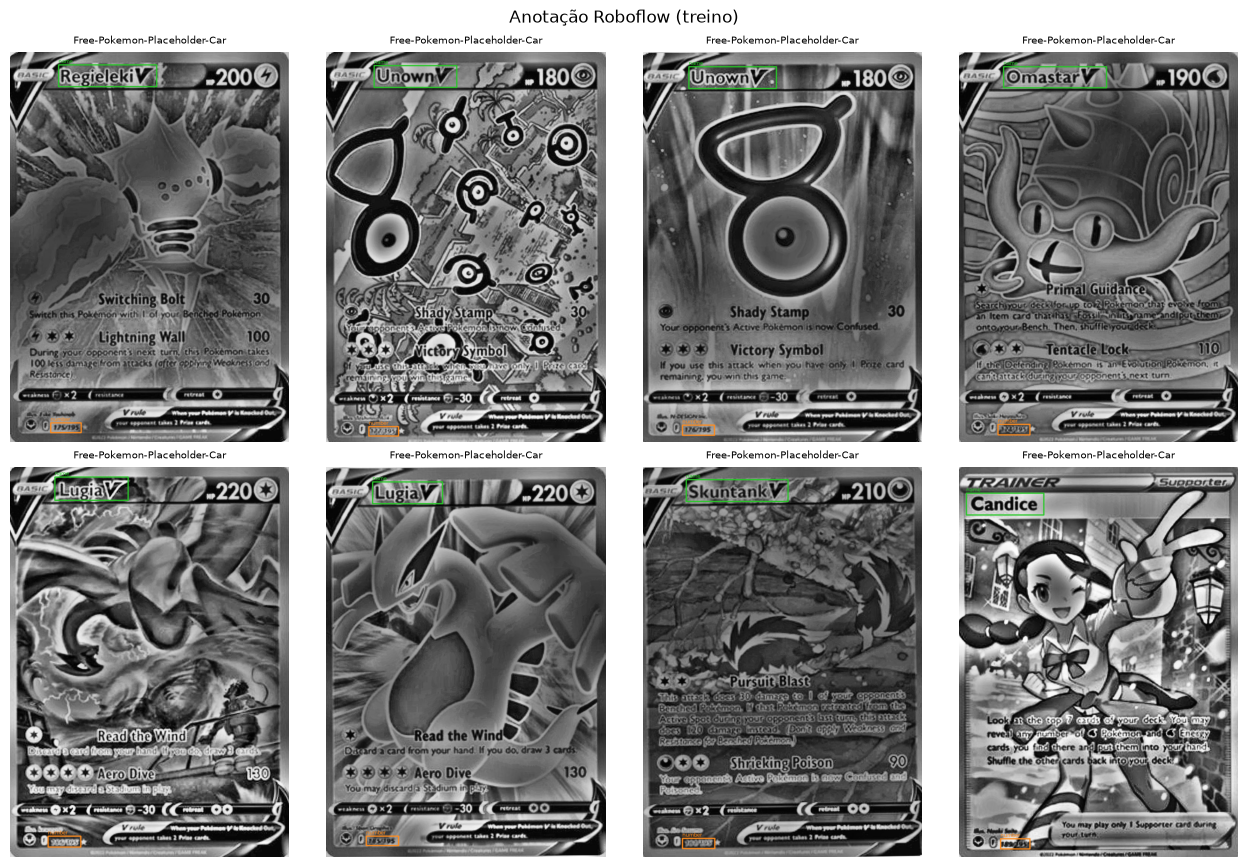

In [69]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

COLORS = {0: (40, 180, 255), 1: (40, 200, 40), 2: (30, 140, 255)}


def draw_obb_label(bgr: np.ndarray, label_path: Path, names: dict) -> np.ndarray:
    vis = bgr.copy()
    h, w = vis.shape[:2]
    text = label_path.read_text(encoding="utf-8").strip()
    if not text:
        return vis
    for line in text.splitlines():
        parts = line.split()
        cid = int(parts[0])
        coords = np.array([float(x) for x in parts[1:]], dtype=np.float32)
        if coords.size == 8:
            pts = coords.reshape(4, 2)
            pts[:, 0] *= w
            pts[:, 1] *= h
        else:
            cx, cy, bw, bh = coords[:4]
            x0, y0 = (cx - bw / 2) * w, (cy - bh / 2) * h
            x1, y1 = (cx + bw / 2) * w, (cy + bh / 2) * h
            pts = np.array([[x0, y0], [x1, y0], [x1, y1], [x0, y1]], dtype=np.float32)
        color = COLORS.get(cid, (200, 200, 200))
        cv2.polylines(vis, [pts.astype(np.int32)], True, color, 2, cv2.LINE_AA)
        x, y = int(pts[:, 0].min()), int(pts[:, 1].min())
        cv2.putText(vis, names.get(cid, str(cid)), (x, max(14, y - 4)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1, cv2.LINE_AA)
    return vis


train_imgs = sorted((DATASET_DIR / "train" / "images").glob("*.jpg"))[:MAX_SHOW]
cols = min(4, max(1, len(train_imgs)))
rows_n = int(np.ceil(len(train_imgs) / cols))
fig, axes = plt.subplots(rows_n, cols, figsize=(3.2 * cols, 4.4 * rows_n))
axes = np.atleast_1d(axes).ravel()
for ax, img_path in zip(axes, train_imgs):
    bgr = cv2.imread(str(img_path))
    lab = DATASET_DIR / "train" / "labels" / (img_path.stem + ".txt")
    vis = draw_obb_label(bgr, lab, names) if lab.exists() else bgr
    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    ax.set_title(img_path.name[:28], fontsize=7)
    ax.axis("off")
for ax in axes[len(train_imgs):]:
    ax.axis("off")
fig.suptitle("Anotação Roboflow (treino)")
plt.tight_layout()
plt.show()


## 3. Train YOLO OBB

Change `VERSION` and run. If `ocr-roi-v1.pt` already exists, the next cell only loads it.


In [70]:
from ultralytics import YOLO

final_pt = WEIGHTS_DIR / f"{EXPERIMENT_NAME}.pt"
best_pt = WEIGHTS_DIR / "best.pt"
if final_pt.exists() or best_pt.exists():
    print(f"Já treinado: {final_pt if final_pt.exists() else best_pt}")
    print("Apague a pasta do run se quiser retreinar.")
else:
    model = YOLO(PRETRAINED_MODEL)
    results = model.train(
        data=str(DATA_YAML.resolve()),
        epochs=EPOCHS,
        imgsz=IMGSZ,
        batch=BATCH,
        patience=PATIENCE,
        seed=SEED,
        workers=WORKERS,
        project=str(PROJECT_DIR),
        name=EXPERIMENT_NAME,
        exist_ok=True,
        device=0 if torch.cuda.is_available() else "cpu",
        **LOSS,
        **AUGMENT,
    )
    bind_run_paths(Path(results.save_dir))
    print(f"Treino em {RUN_DIR}")


Já treinado: C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\OCR\runs\ocr-roi-v1\weights\ocr-roi-v1.pt
Apague a pasta do run se quiser retreinar.


## 4. Validate and copy weights


In [71]:
from shutil import copy2

_existing = find_existing_run_dir()
if _existing:
    bind_run_paths(_existing)

best_pt = WEIGHTS_DIR / "best.pt"
named_pt = WEIGHTS_DIR / f"{EXPERIMENT_NAME}.pt"
if best_pt.exists() and not named_pt.exists():
    copy2(best_pt, named_pt)
WEIGHTS = named_pt if named_pt.exists() else best_pt
if not WEIGHTS.exists():
    raise FileNotFoundError(f"Treine antes. Faltando: {WEIGHTS_DIR}")

roi_model = YOLO(str(WEIGHTS))
val = roi_model.val(
    data=str(DATA_YAML.resolve()),
    split="val",
    imgsz=IMGSZ,
    batch=BATCH,
    workers=WORKERS,
    device=0 if torch.cuda.is_available() else "cpu",
    plots=True,
)
print(f"Pesos : {WEIGHTS}")
metrics = getattr(val, "obb", None) or getattr(val, "box", None)
if metrics is not None:
    print(f"mAP50 : {float(metrics.map50):.3f}   mAP50-95: {float(metrics.map):.3f}")
else:
    print(getattr(val, "results_dict", val))


Ultralytics 8.4.129  Python-3.14.7 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5060, 8150MiB)
YOLOv8n-obb summary (fused): 82 layers, 3,077,804 parameters, 0 gradients, 8.3 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 698.674.4 MB/s, size: 134.7 KB)
val: Scanning C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\OCR\data\valid\labels.cache... 59 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 59/59 20.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 3.0it/s 1.4s0.6s
                   all         59        149      0.979      0.989      0.977      0.807
             colection         32         33       0.98       0.97      0.965      0.818
                  name         58         58      0.975          1       0.98      0.816
                number         58         58      0.983      0.997      0.985      0.786
Speed: 0.4ms preprocess, 2.7ms inference, 0.0ms loss, 3.0ms postprocess p

## 5. ROI evaluation metrics

Same numbers as the card detector: **mAP@0.50**, **mAP@0.50:0.95**, precision, recall, and per-class AP on **val** and **test**. Saved under `src/roi/runs/<experiment>/metrics/`.


In [ ]:
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import yaml

CLASS_NAMES = yaml.safe_load(DATA_YAML.read_text(encoding="utf-8")).get("names") or {}
if isinstance(CLASS_NAMES, list):
    CLASS_NAMES = dict(enumerate(CLASS_NAMES))


def _to_float(value) -> float | None:
    if value is None:
        return None
    try:
        if hasattr(value, "item"):
            return float(value.item())
        arr = np.asarray(value)
        if arr.size == 1:
            return float(arr.reshape(-1)[0])
        return float(value)
    except (TypeError, ValueError):
        return None


def _to_list(value) -> list[float]:
    if value is None:
        return []
    try:
        return [float(x) for x in np.atleast_1d(np.asarray(value, dtype=float)).reshape(-1)]
    except (TypeError, ValueError):
        return []


def get_obb_namespace(metrics_obj) -> tuple[Any, str]:
    if hasattr(metrics_obj, "obb") and metrics_obj.obb is not None:
        ns = metrics_obj.obb
        if _to_float(getattr(ns, "map", None)) is not None:
            return ns, "obb"
    if hasattr(metrics_obj, "box") and metrics_obj.box is not None:
        return metrics_obj.box, "box"
    raise AttributeError("No metrics.obb or metrics.box on the val result.")


def global_rows(metrics_obj, split: str) -> list[dict]:
    ns, source = get_obb_namespace(metrics_obj)
    mapping = [
        ("mAP@0.50:0.95", "map"),
        ("mAP@0.50", "map50"),
        ("mAP@0.75", "map75"),
        ("Precision", "mp"),
        ("Recall", "mr"),
    ]
    rows = []
    for label, attr in mapping:
        rows.append({"split": split, "metric": label, "value": _to_float(getattr(ns, attr, None)), "source": source})
    return rows


def class_rows(metrics_obj, split: str) -> list[dict]:
    ns, _ = get_obb_namespace(metrics_obj)
    p = _to_list(getattr(ns, "p", None))
    r = _to_list(getattr(ns, "r", None))
    ap50 = _to_list(getattr(ns, "ap50", None))
    ap = _to_list(getattr(ns, "ap", None))
    maps = _to_list(getattr(ns, "maps", None))
    n = max(len(CLASS_NAMES), len(p), len(r), len(ap50), len(ap), len(maps), 1)
    rows = []
    for i in range(n):
        rows.append(
            {
                "split": split,
                "class": CLASS_NAMES.get(i, str(i)),
                "precision": p[i] if i < len(p) else None,
                "recall": r[i] if i < len(r) else None,
                "AP50": ap50[i] if i < len(ap50) else None,
                "AP50-95": ap[i] if i < len(ap) else (maps[i] if i < len(maps) else None),
            }
        )
    return rows


device = 0 if torch.cuda.is_available() else "cpu"
global_all: list[dict] = []
class_all: list[dict] = []
for split in ("val", "test"):
    result = roi_model.val(
        data=str(DATA_YAML.resolve()),
        split=split,
        imgsz=IMGSZ,
        batch=BATCH,
        workers=WORKERS,
        device=device,
        verbose=False,
        plots=False,
        project=str(PROJECT_DIR),
        name=f"{EXPERIMENT_NAME}-{split}-metrics",
        exist_ok=True,
    )
    global_all.extend(global_rows(result, split))
    class_all.extend(class_rows(result, split))
    ns, _ = get_obb_namespace(result)
    print(f"{split:4s}  mAP50={float(ns.map50):.3f}  mAP50-95={float(ns.map):.3f}  P={float(ns.mp):.3f}  R={float(ns.mr):.3f}")

metrics_dir = RUN_DIR / "metrics"
metrics_dir.mkdir(parents=True, exist_ok=True)
global_df = pd.DataFrame(global_all)
class_df = pd.DataFrame(class_all)
global_path = metrics_dir / "roi_metrics.csv"
class_path = metrics_dir / "roi_metrics_per_class.csv"
global_df.to_csv(global_path, index=False, encoding="utf-8")
class_df.to_csv(class_path, index=False, encoding="utf-8")
print("\nGlobal")
display(global_df)
print("Per class")
display(class_df)

fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.2))
piv = global_df.pivot(index="metric", columns="split", values="value")
piv.plot(kind="bar", ax=axes[0], color=["#0969da", "#2ea44f"], rot=20)
axes[0].set_ylim(0, 1.05)
axes[0].set_title("ROI detector — val vs test")
axes[0].set_ylabel("Score")
axes[0].legend(frameon=False)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

test_cls = class_df[class_df["split"] == "test"]
if not test_cls.empty:
    x = np.arange(len(test_cls))
    w = 0.35
    axes[1].bar(x - w / 2, test_cls["AP50"].fillna(0), w, color="#8250df", label="AP50")
    axes[1].bar(x + w / 2, test_cls["recall"].fillna(0), w, color="#1a7f37", label="Recall")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(test_cls["class"])
    axes[1].set_ylim(0, 1.05)
    axes[1].set_title("Test — per class")
    axes[1].legend(frameon=False)
    axes[1].spines["top"].set_visible(False)
    axes[1].spines["right"].set_visible(False)
fig.tight_layout()
fig_path = metrics_dir / "roi_metrics.png"
fig.savefig(fig_path, dpi=140, bbox_inches="tight")
plt.show()
print("CSV:", global_path)
print("    ", class_path)
print("FIG:", fig_path)


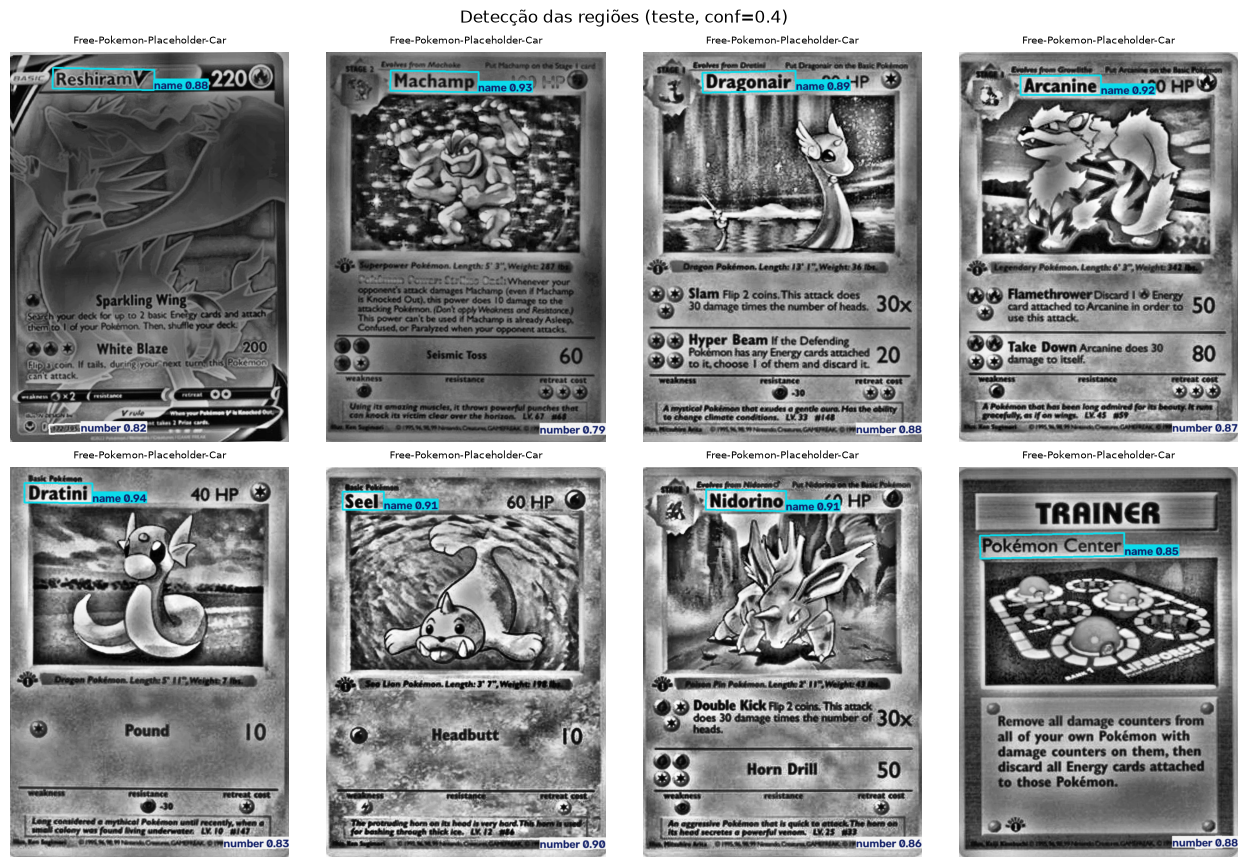

In [72]:
test_dir = DATASET_DIR / "test" / "images"
test_imgs = sorted(p for p in test_dir.glob("*") if p.suffix.lower() in {".jpg", ".jpeg", ".png"})
show = test_imgs[:MAX_SHOW]
if not show:
    raise FileNotFoundError(test_dir)

preds = roi_model.predict(
    source=[str(p) for p in show],
    conf=CONF,
    imgsz=IMGSZ,
    device=0 if torch.cuda.is_available() else "cpu",
    verbose=False,
)

cols = min(4, len(show))
rows_n = int(np.ceil(len(show) / cols))
fig, axes = plt.subplots(rows_n, cols, figsize=(3.2 * cols, 4.4 * rows_n))
axes = np.atleast_1d(axes).ravel()
for ax, result in zip(axes, preds):
    vis = result.plot()
    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    ax.set_title(Path(result.path).name[:28], fontsize=7)
    ax.axis("off")
for ax in axes[len(show):]:
    ax.axis("off")
fig.suptitle(f"Detecção das regiões (teste, conf={CONF})")
plt.tight_layout()
plt.show()
